In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score,balanced_accuracy_score
import os

## Load the .csv table that sum up the annotations the 6 raters made.

In [ ]:
merged = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/PCS_annotation/acc_sulpated/merged/merged_patterns.csv")
merged.head()

In [4]:
sex_age_info = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/PCS_annotation/100_SEX_AGE_strat.csv")
sex_age_info["Subject"] = sex_age_info["Subject"].apply(lambda x: int(x[-7:]))
sex_age_info["Sex"] = sex_age_info["Sex"].apply(lambda x: "Male" if x==1 else "Female")

### Check the statistical results for the paracingulate sulcus, for both hemispheres.

In [5]:
only_PCS = ["A_PCS", "B_PCS", "C_PCS", "D_PCS", "E_PCS", "F_PCS"]

print("Left side:", '\n')
print(merged[merged["side"]=="left"][only_PCS].describe(), '\n')

print("Right side:", '\n')
print(merged[merged["side"]=="right"][only_PCS].describe(), '\n')

Left side: 

        A_PCS       B_PCS       C_PCS       D_PCS       E_PCS       F_PCS
count  100.00  100.000000  100.000000  100.000000  100.000000  100.000000
mean     0.45    0.470000    0.580000    0.610000    0.500000    0.420000
std      0.50    0.501614    0.496045    0.490207    0.502519    0.496045
min      0.00    0.000000    0.000000    0.000000    0.000000    0.000000
25%      0.00    0.000000    0.000000    0.000000    0.000000    0.000000
50%      0.00    0.000000    1.000000    1.000000    0.500000    0.000000
75%      1.00    1.000000    1.000000    1.000000    1.000000    1.000000
max      1.00    1.000000    1.000000    1.000000    1.000000    1.000000 

Right side: 

            A_PCS       B_PCS       C_PCS       D_PCS       E_PCS       F_PCS
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000
mean     0.340000    0.330000    0.400000    0.410000    0.300000    0.350000
std      0.476095    0.472582    0.492366    0.494311    0.460566    0.

### To check if the PCS+ (prominent PCS) are also labeled as PCS

In [6]:
for i in ["A", "B", "C", "D", "E", "F"]:
    print(f"Subject {i}")
    print(((merged[f"{i}_PCS"] == 0) & (merged[f"{i}_PCS+"] == 1)).sum())

Subject A
0
Subject B
0
Subject C
0
Subject D
0
Subject E
0
Subject F
0


### Cohen’s kappa: a statistic that measures inter-annotator agreement.

In [7]:
merged[only_PCS].corr()

,A_PCS,B_PCS,C_PCS,D_PCS,E_PCS,F_PCS
A_PCS,1.000000,0.676446,0.660661,0.710175,0.697324,0.579828
B_PCS,0.676446,1.000000,0.649245,0.718661,0.750000,0.570513
C_PCS,0.660661,0.649245,1.000000,0.640656,0.628828,0.601647
D_PCS,0.710175,0.718661,0.640656,1.000000,0.698244,0.446662
E_PCS,0.697324,0.750000,0.628828,0.698244,1.000000,0.465639
F_PCS,0.579828,0.570513,0.601647,0.446662,0.465639,1.000000


In [8]:
from itertools import combinations 

# all the possible pairs from the list of raters
res = list(combinations(only_PCS, 2))

# empty DataFrame to store kappa scores
kappa_matrix = pd.DataFrame(np.nan, index=only_PCS, columns=only_PCS)

for rater_1, rater_2 in res:
    score = cohen_kappa_score(merged[rater_1], merged[rater_2])
    kappa_matrix.loc[rater_1, rater_2] = score
    kappa_matrix.loc[rater_2, rater_1] = score  # fill symmetric value

# diagonal with 1.0 (perfect agreement with self)
np.fill_diagonal(kappa_matrix.values, 1.0)

print(kappa_matrix.round(2))

       A_PCS  B_PCS  C_PCS  D_PCS  E_PCS  F_PCS
A_PCS   1.00   0.68   0.65   0.69   0.70   0.58
B_PCS   0.68   1.00   0.64   0.70   0.75   0.57
C_PCS   0.65   0.64   1.00   0.64   0.62   0.59
D_PCS   0.69   0.70   0.64   1.00   0.68   0.43
E_PCS   0.70   0.75   0.62   0.68   1.00   0.47
F_PCS   0.58   0.57   0.59   0.43   0.47   1.00


### Number of commun labelisation to the rater A

In [9]:
(merged[only_PCS].eq(merged[only_PCS].iloc[:, 0], axis=0)).sum(axis=1)

0      6
1      6
2      6
3      5
4      5
      ..
195    1
196    4
197    6
198    6
199    1
Length: 200, dtype: int64

In [10]:
(merged[only_PCS].eq(merged[only_PCS].iloc[:, 5], axis=0)).sum(axis=1).mean()/6

0.8083333333333332

In [11]:
(merged[only_PCS].eq(merged[only_PCS].iloc[:, 5], axis=0)).sum(axis=1)

0      6
1      6
2      6
3      1
4      1
      ..
195    5
196    2
197    6
198    6
199    5
Length: 200, dtype: int64

In [12]:
for i in range(2,7):
    print(f"There is at least {i-1} commun labelisation to the rater A, for 5 other raters:")
    print(((merged[only_PCS].eq(merged[only_PCS].iloc[:, 0], axis=0)).sum(axis=1)>=i).sum())

There is at least 1 commun labelisation to the rater A, for 5 other raters:
196
There is at least 2 commun labelisation to the rater A, for 5 other raters:
187
There is at least 3 commun labelisation to the rater A, for 5 other raters:
180
There is at least 4 commun labelisation to the rater A, for 5 other raters:
156
There is at least 5 commun labelisation to the rater A, for 5 other raters:
115


### Annotation and sex and age

In [ ]:
all_results = pd.merge(sex_age_info, merged[only_PCS+["subject", "side"]], left_on="Subject", right_on="subject", how='inner')
all_results = all_results.drop('subject', axis=1)
all_results["PCS"] = (all_results[only_PCS].sum(axis=1) >= 3)
all_results["PCS"] = all_results["PCS"].apply(lambda x: 1 if x else 0)

In [ ]:
#all_results[all_results[only_PCS].sum(axis=1) == 3]

In [23]:
#all_results.to_csv('/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/PCS_annotation/merged_simplified.csv', index=False)

In [16]:
import seaborn as sns

Text(0.5, 1.0, 'Number of PCS in the left hemisphere, regarding the sex')

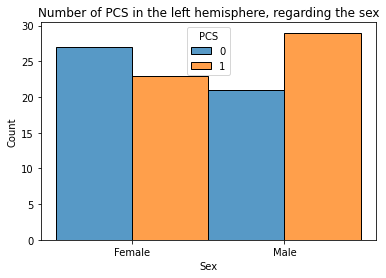

In [17]:
sns.histplot(data=all_results[all_results["side"]=="left"], x="Sex", hue="PCS", multiple="dodge")
plt.title('Number of PCS in the left hemisphere, regarding the sex')

Text(0.5, 1.0, 'Number of PCS in the right hemisphere, regarding the sex')

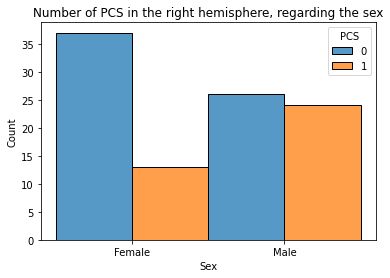

In [18]:
sns.histplot(data=all_results[all_results["side"]=="right"], x="Sex", hue="PCS", multiple="dodge",)
plt.title('Number of PCS in the right hemisphere, regarding the sex')

In [ ]:
#all_results[["Subject", "Sex", "Age", "side", "PCS"]]

In [27]:
def assign_age_group(age):
    if age <= 62 :   # roughly 50.7 ± 1.5
        return 51
    elif 62 <= age : # roughly 76.5 ± 1.5
        return 77
    else:
        return None  # exclude others if any

df = all_results.copy()
df["AgeGroup"] = df["Age"].apply(assign_age_group)

prop_df = (
    df.groupby(["side", "AgeGroup", "PCS"])
      .size()
      .groupby(level=[0,1])
      .apply(lambda x: x / x.sum())
      .reset_index(name="Proportion")
)

prop_df

,side,AgeGroup,PCS,Proportion
0,left,51,0,0.48
1,left,51,1,0.52
2,left,77,0,0.48
3,left,77,1,0.52
4,right,51,0,0.64
5,right,51,1,0.36
6,right,77,0,0.62
7,right,77,1,0.38


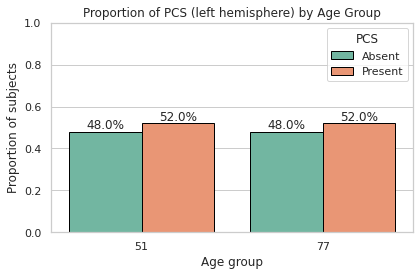

In [35]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=prop_df[prop_df["side"]=="left"], 
    x="AgeGroup", 
    y="Proportion", 
    hue="PCS",
    palette="Set2",
    edgecolor="black"
)

# Add text labels (proportions as percentages)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", labels=[f"{h.get_height()*100:.1f}%" for h in container])

# Title and labels
plt.title("Proportion of PCS (left hemisphere) by Age Group")
plt.ylabel("Proportion of subjects")
plt.xlabel("Age group")
plt.ylim(0, 1)

# Fix legend so it shows colored boxes, not lines
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ["Absent", "Present"], title="PCS", frameon=True)

plt.tight_layout()
plt.savefig(
    "/volatile/ad279118/2025_Imaging_Genetics/V4/PCS_left_proportion.png",   # or ".pdf", ".tiff", etc.
    dpi=600,                     # 600 dpi is good for print, 300 for slides
    bbox_inches="tight",         # trims extra whitespace
    transparent=True             # optional — removes white background
)
plt.show()

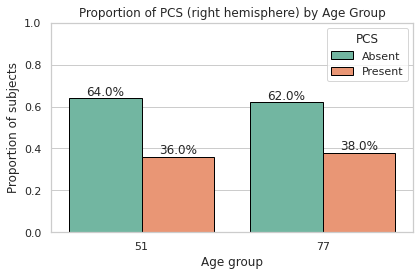

In [36]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=prop_df[prop_df["side"]=="right"], 
    x="AgeGroup", 
    y="Proportion", 
    hue="PCS",
    palette="Set2",
    edgecolor="black"
)

# Add text labels (proportions as percentages)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", labels=[f"{h.get_height()*100:.1f}%" for h in container])

# Title and labels
plt.title("Proportion of PCS (right hemisphere) by Age Group")
plt.ylabel("Proportion of subjects")
plt.xlabel("Age group")
plt.ylim(0, 1)

# Fix legend so it shows colored boxes, not lines
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ["Absent", "Present"], title="PCS", frameon=True)

plt.tight_layout()
plt.savefig(
    "/volatile/ad279118/2025_Imaging_Genetics/V4/PCS_right_proportion.png",   # or ".pdf", ".tiff", etc.
    dpi=600,                     # 600 dpi is good for print, 300 for slides
    bbox_inches="tight",         # trims extra whitespace
    transparent=True             # optional — removes white background
)
plt.show()

Text(0.5, 1.0, 'Number of PCS in the left hemisphere, regarding the age')

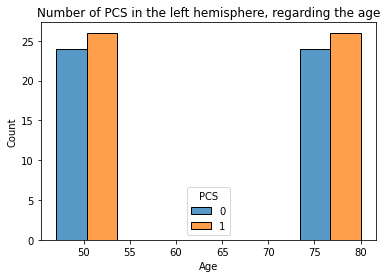

In [17]:
sns.histplot(data=all_results[all_results["side"]=="left"], x="Age", hue="PCS", bins=5, multiple="dodge")
plt.title('Number of PCS in the left hemisphere, regarding the age')

Text(0.5, 1.0, 'Number of PCS in the right hemisphere, regarding the age')

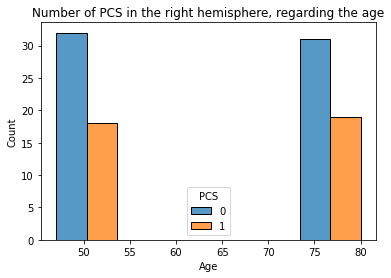

In [18]:
sns.histplot(data=all_results[all_results["side"]=="right"], x="Age", hue="PCS", bins=5, multiple="dodge")
plt.title('Number of PCS in the right hemisphere, regarding the age')

# Comparison with the model trained on the ACC dataset

In [19]:
automatic_path = "/volatile/ad279118/2025_Imaging_Genetics/UKB_cingulate_pred"

In [ ]:
left_pred = pd.read_csv(f"{automatic_path}/UKB_left_pred.csv")
all_results_left = pd.merge(all_results[all_results["side"]=="left"], left_pred, left_on="Subject", right_on="IID", how='inner')
all_results_left = all_results_left.drop('IID', axis=1)
left_bin_pred = pd.read_csv(f"{automatic_path}/UKB_bin_left_pred.csv")
all_results_left = pd.merge(all_results_left, left_bin_pred, left_on="Subject", right_on="IID", how='inner')
all_results_left = all_results_left.drop('IID', axis=1)
all_results_left['BAge'] = (all_results_left['Age'] > 60).apply(lambda x:int(x))
#all_results_left

<AxesSubplot:xlabel='Age', ylabel='Count'>

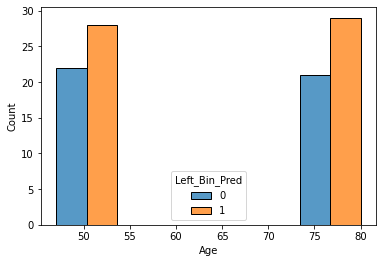

In [38]:
sns.histplot(all_results_left, x="Age", hue="Left_Bin_Pred", bins=5, multiple="dodge")

In [39]:
arloung = all_results_left[all_results_left["BAge"]==0]

roc_auc_score(arloung["PCS"],arloung["Left_Prob_Pred"]), balanced_accuracy_score(arloung["PCS"], arloung["Left_Bin_Pred"])

(0.9342948717948718, 0.8782051282051282)

In [40]:
arlold = all_results_left[all_results_left["BAge"]==1]

roc_auc_score(arlold["PCS"],arlold["Left_Prob_Pred"]), balanced_accuracy_score(arlold["PCS"], arlold["Left_Bin_Pred"])

(0.7676282051282052, 0.6971153846153846)

<AxesSubplot:xlabel='Left_Prob_Pred', ylabel='Count'>

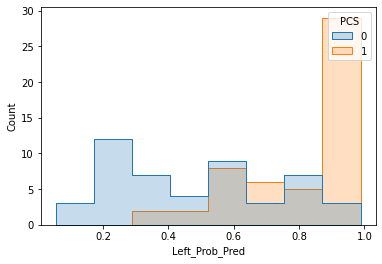

In [41]:
sns.histplot(all_results_left, x="Left_Prob_Pred", hue="PCS", element="step")

In [42]:
roc_auc_score(all_results_left["PCS"],all_results_left["Left_Prob_Pred"]), balanced_accuracy_score(all_results_left["PCS"], all_results_left["Left_Bin_Pred"])

(0.858573717948718, 0.7876602564102564)

In [ ]:
right_pred = pd.read_csv(f"{automatic_path}/UKB_right_pred.csv")
all_results_right = pd.merge(all_results[all_results["side"]=="right"], right_pred, left_on="Subject", right_on="IID", how='inner')
all_results_right = all_results_right.drop('IID', axis=1)
right_bin_pred = pd.read_csv(f"{automatic_path}/UKB_bin_right_pred.csv")
all_results_right = pd.merge(all_results_right, right_bin_pred, left_on="Subject", right_on="IID", how='inner')
all_results_right = all_results_right.drop('IID', axis=1)
all_results_right['BAge'] = (all_results_right['Age'] > 60).apply(lambda x:int(x))
#all_results_right

<AxesSubplot:xlabel='Age', ylabel='Count'>

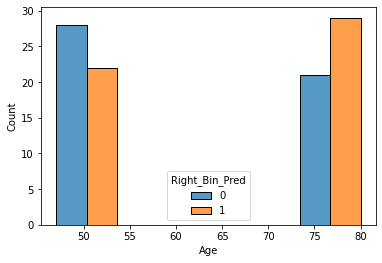

In [44]:
sns.histplot(all_results_right, x="Age", hue="Right_Bin_Pred", bins=5, multiple="dodge")

<AxesSubplot:xlabel='Right_Prob_Pred', ylabel='Count'>

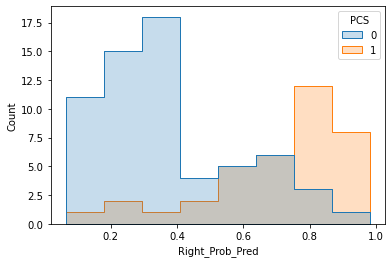

In [45]:
sns.histplot(all_results_right, x="Right_Prob_Pred", hue="PCS", element="step")

In [47]:
arroung = all_results_right[all_results_right["BAge"]==0]

roc_auc_score(arroung["PCS"],arroung["Right_Prob_Pred"]), balanced_accuracy_score(arroung["PCS"], arroung["Right_Bin_Pred"])

(0.892361111111111, 0.8506944444444444)

In [48]:
arrold = all_results_right[all_results_right["BAge"]==1]

roc_auc_score(arrold["PCS"],arrold["Right_Prob_Pred"]), balanced_accuracy_score(arrold["PCS"], arrold["Right_Bin_Pred"])

(0.8149405772495755, 0.7538200339558574)

In [29]:
roc_auc_score(all_results_right["PCS"],all_results_right["Right_Prob_Pred"]), balanced_accuracy_score(all_results_right["PCS"], all_results_right["Right_Bin_Pred"])

(0.8562848562848564, 0.803088803088803)

### Kapa beween the models and the raters

In [89]:
# all the possible pairs from the list of raters
res = list(combinations(only_PCS+["Right_Bin_Pred"], 2))

# empty DataFrame to store kappa scores
kappa_matrix = pd.DataFrame(np.nan, index=only_PCS+["Right_Bin_Pred"], columns=only_PCS+["Right_Bin_Pred"],)

for rater_1, rater_2 in res:
    score = cohen_kappa_score(all_results_right[rater_1], all_results_right[rater_2])
    kappa_matrix.loc[rater_1, rater_2] = score
    kappa_matrix.loc[rater_2, rater_1] = score  # fill symmetric value

np.fill_diagonal(kappa_matrix.values, 1.0)

print(kappa_matrix.round(2))

                A_PCS  B_PCS  C_PCS  D_PCS  E_PCS  F_PCS  Right_Bin_Pred
A_PCS            1.00   0.71   0.66   0.68   0.68   0.62            0.50
B_PCS            0.71   1.00   0.64   0.74   0.75   0.51            0.44
C_PCS            0.66   0.64   1.00   0.65   0.57   0.68            0.54
D_PCS            0.68   0.74   0.65   1.00   0.63   0.45            0.60
E_PCS            0.68   0.75   0.57   0.63   1.00   0.48            0.42
F_PCS            0.62   0.51   0.68   0.45   0.48   1.00            0.40
Right_Bin_Pred   0.50   0.44   0.54   0.60   0.42   0.40            1.00


In [90]:
# all the possible pairs from the list of raters
res = list(combinations(only_PCS+["Left_Bin_Pred"], 2))

# empty DataFrame to store kappa scores
kappa_matrix = pd.DataFrame(np.nan, index=only_PCS+["Left_Bin_Pred"], columns=only_PCS+["Left_Bin_Pred"],)

for rater_1, rater_2 in res:
    score = cohen_kappa_score(all_results_left[rater_1], all_results_left[rater_2])
    kappa_matrix.loc[rater_1, rater_2] = score
    kappa_matrix.loc[rater_2, rater_1] = score  # fill symmetric value

np.fill_diagonal(kappa_matrix.values, 1.0)

print(kappa_matrix.round(2))

               A_PCS  B_PCS  C_PCS  D_PCS  E_PCS  F_PCS  Left_Bin_Pred
A_PCS           1.00   0.64   0.63   0.69   0.70   0.53           0.53
B_PCS           0.64   1.00   0.62   0.64   0.74   0.62           0.44
C_PCS           0.63   0.62   1.00   0.61   0.64   0.49           0.49
D_PCS           0.69   0.64   0.61   1.00   0.70   0.40           0.55
E_PCS           0.70   0.74   0.64   0.70   1.00   0.44           0.50
F_PCS           0.53   0.62   0.49   0.40   0.44   1.00           0.39
Left_Bin_Pred   0.53   0.44   0.49   0.55   0.50   0.39           1.00


In [92]:
cohen_kappa_score(all_results_right["PCS"], all_results_right["Right_Bin_Pred"])

0.5622761639474732

In [93]:
cohen_kappa_score(all_results_left["PCS"], all_results_left["Left_Bin_Pred"])


0.5776347546259051

### Get the subjects where there is a difference between the ground truth and the automatic labelisation

In [ ]:
all_results_right[all_results_right["PCS"] != all_results_right["Right_Bin_Pred"]].Subject.to_list()

In [ ]:
all_results_left[all_results_left["PCS"] != all_results_left["Left_Bin_Pred"]].Subject.to_list()